In [1]:
import torch
import torch.nn as nn
import json
import os
import pandas as pd
from models.lstm import LSTM
from utils.dataset import TranslateDataset
from torch.utils.data import DataLoader
import tokenizers
import numpy as np
from tqdm import tqdm

In [2]:
df_eval = pd.read_parquet("data/tokenized_eval.parquet")

In [3]:
tokenizer = tokenizers.Tokenizer.from_file("artifacts/tokenizer_10000.json")

In [4]:
dataset_eval = TranslateDataset(
    tokens_src=df_eval['en_tokens'].tolist(),
    tokens_tgt=df_eval['pt_tokens'].tolist(),
    invert_src=True
)

dataloader_eval = DataLoader(dataset_eval, batch_size=128, shuffle=False)

In [ ]:
PATH_MODELS = "artifacts"

models = {}
for file in os.listdir(PATH_MODELS):
    if file.endswith(".pt"):
        model_name = file[:-3].split("_")[1]
        model_path = os.path.join(PATH_MODELS, file)
        model_config_path = os.path.join("configs", f"{model_name}_config.json")
        
        with open(model_config_path, 'r', encoding='utf-8') as f:
            model_config = json.load(f)
        
        
        model = LSTM(embedding_dim=model_config["embedding_dim"],
                     encoder_bidirectional=model_config["encoder_bidirectional"],
                     encoder_hidden_dim=model_config["encoder_hidden_dim"],
                     encoder_num_layers=model_config["encoder_num_layers"],
                     decoder_hidden_dim=model_config["decoder_hidden_dim"],
                     decoder_num_layers=model_config["decoder_num_layers"],
                     encoder_dropout=model_config["encoder_dropout"],
                     decoder_dropout=model_config["decoder_dropout"],
                     vocab_size=10000, 
                     pad_idx=0)
        model.load_state_dict(torch.load(model_path))
        model.to("cuda" if torch.cuda.is_available() else "cpu")
        model.eval()
        models[model_name] = model
    

In [6]:
print(models.keys())

dict_keys(['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8'])


In [7]:
for model_name, model in models.items():
    print(f"Model: {model_name}")
    total_outputs = []
    for batch in tqdm(dataloader_eval, total=len(dataloader_eval), desc=f"Evaluating {model_name}"):
        enc_tokens, dec_tokens = batch
        enc_tokens = enc_tokens.to('cuda' if torch.cuda.is_available() else 'cpu')
        dec_tokens = dec_tokens.to('cuda' if torch.cuda.is_available() else 'cpu')

        with torch.no_grad():
            outputs = model(enc_tokens, dec_tokens[:, :-1])
        
        outputs = outputs.argmax(dim=-1)

        total_outputs.append(outputs.cpu().numpy())

    total_outputs = np.concatenate(total_outputs, axis=0)

    df_eval[f'{model_name}_pred'] = tokenizer.decode_batch(total_outputs, skip_special_tokens=True)

Model: v1


Evaluating v1: 100%|██████████| 123/123 [00:01<00:00, 84.65it/s]


Model: v2


Evaluating v2: 100%|██████████| 123/123 [00:02<00:00, 46.25it/s]


Model: v3


...

Evaluating v6: 100%|██████████| 123/123 [00:01<00:00, 76.17it/s]


Model: v7


Evaluating v7: 100%|██████████| 123/123 [00:03<00:00, 32.14it/s]


Model: v8


Evaluating v8: 100%|██████████| 123/123 [00:03<00:00, 32.20it/s]


In [ ]:
df_configs = pd.DataFrame([json.load(open(os.path.join("configs", f))) for f in os.listdir("configs") if f.endswith("_config.json")])
df_configs

,invert_src,embedding_dim,encoder_hidden_dim,decoder_hidden_dim,encoder_num_layers,decoder_num_layers,encoder_dropout,decoder_dropout,encoder_bidirectional,batch_size,...,save_steps,eval_steps,device,desc,name,early_stop_patience,early_stop_min_delta,warmup_steps,max_steps,learning_rate
0,True,256,512,512,2,2,0.1,0.1,True,256,...,1000,1000,cuda,Treinamento inicial,v1,5000,0.0,NaN,NaN,NaN
1,True,256,1024,1024,2,2,0.1,0.1,True,256,...,1000,1000,cuda,Aumentando o hidden size do encoder e do decod...,v2,5000,0.0,NaN,NaN,NaN
2,True,256,1024,1024,2,2,0.1,0.3,True,256,...,1000,1000,cuda,Adicionando dropout no decoder para evitar ove...,v3,5000,0.0,NaN,NaN,NaN
3,True,256,512,512,2,2,0.1,0.1,True,1024,...,1000,1000,cuda,Aumentando o batchsize do v1 para treinar mais...,v4,5000,0.0,NaN,NaN,NaN
4,True,256,512,512,2,2,0.1,0.1,True,1024,...,1000,1000,cuda,Adicionando warmup na v4,v5,5000,0.0,5000.0,200000.0,NaN
5,True,256,512,512,3,3,0.3,0.1,True,512,...,1000,1000,cuda,Treinando um modelo mais parrudo,v6,5000,0.0,5000.0,200000.0,0.0001
6,True,512,1024,1024,3,3,0.1,0.1,True,256,...,1000,1000,cuda,Treinando um modelo mais parrudo,v7,5000,0.0,25000.0,200000.0,0.0001
7,True,512,1024,1024,3,3,0.1,0.4,True,256,...,1000,1000,cuda,Treinando um modelo mais parrudo com dropout n...,v8,5000,0.0,25000.0,200000.0,0.0001


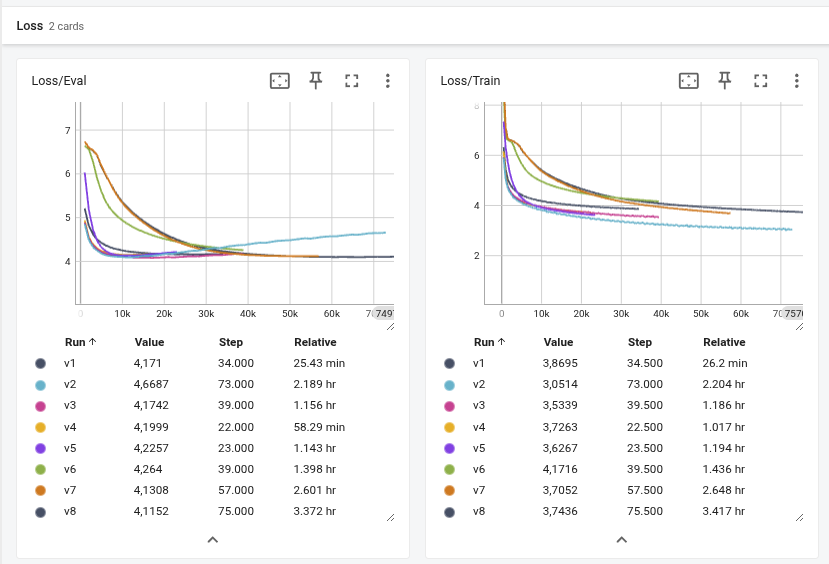

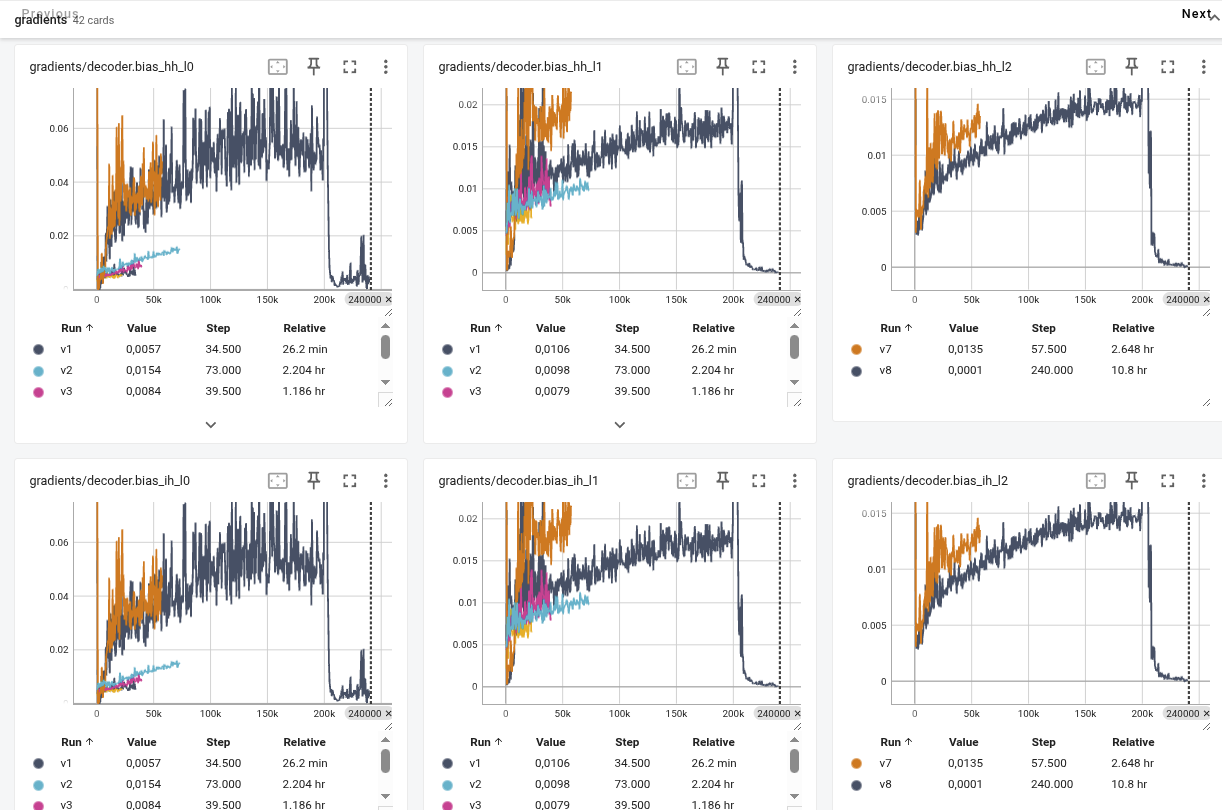

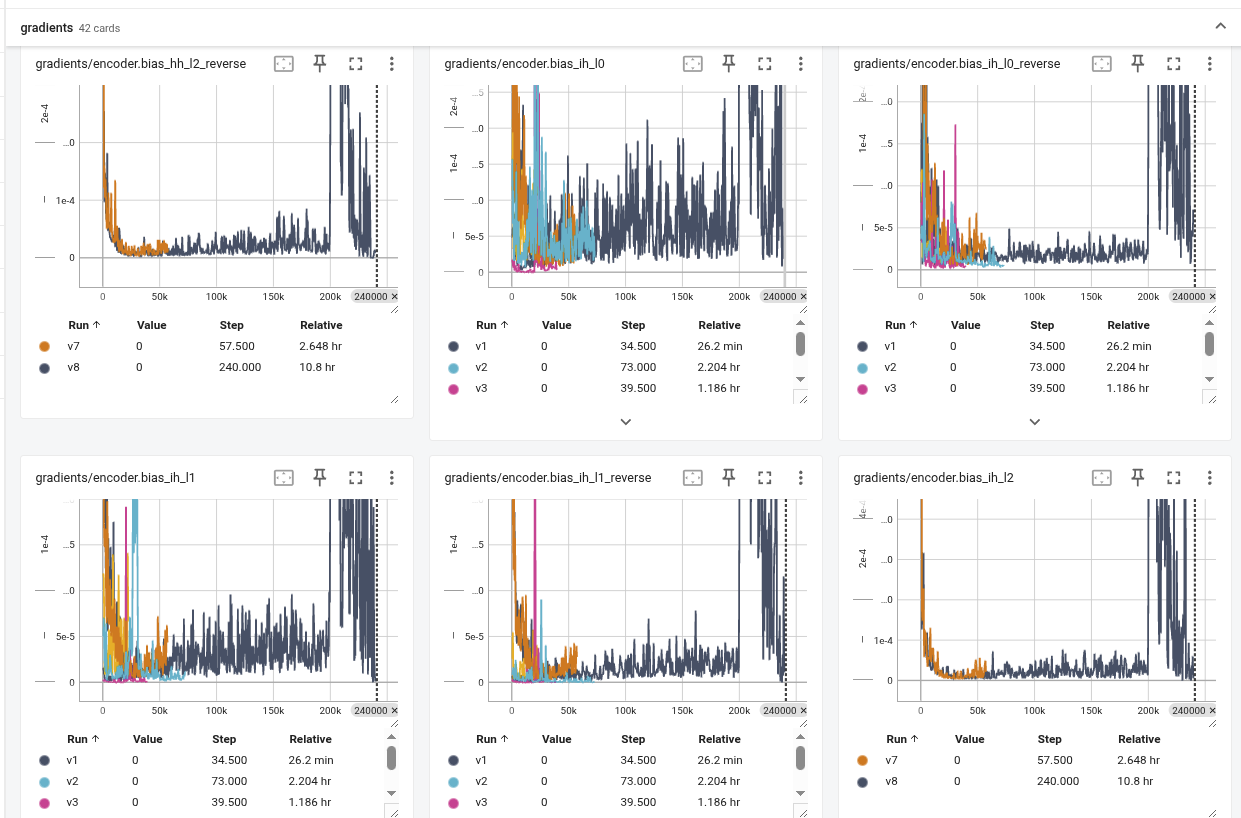

In [12]:
index = 1
model_test = 'v7_pred'
print(df_eval['en'].iloc[index])
print(df_eval['pt'].iloc[index])
print(df_eval[model_test].iloc[index])

Joseph smith himself ordered a company of danites to put right physically that which is not right, and to cleanse the church of very great evils.
Joseph smith que se mandou ele mesmo uma companhia de danites pôr direito fisicamente que não é correto, e limpar a igreja de muito grandes males.
E un ph,, você recus para não, vez de futebol ia, - a icamente em ele tenha um to. mas que a sua. um mais. ditos..........


In [ ]:
for model_name, model in models.items():
    print(f"Model: {model_name}")
    eval_tokens = df_tokenized_eval['enc_tokens'].tolist()